# EEG Emotional State Recognition
**Dataset:** EEG Brainwave Dataset - Feeling Emotions (Kaggle)

This notebook covers:
1. Exploratory Data Analysis (EDA)
2. Classical ML Models (Logistic Regression, SVM, Random Forest, XGBoost, LightGBM)
3. Deep Learning Models (MLP, 1D-CNN, Transformer)
4. Model Comparison

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch device: cpu")
print(f"PyTorch version: {torch.__version__}")

PyTorch device: cpu
PyTorch version: 2.11.0+cpu


## 1. Load Data

In [2]:
df = pd.read_csv('data/emotions.csv')
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Features: {df.shape[1] - 1}")
df.head()

Shape: (2132, 2549)
Rows: 2132, Features: 2548


,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a,mean_d_4_a,...,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b,label
0,4.62,30.3,-356.0,15.6,26.3,1.070,0.411,-15.70,2.06,3.15,...,23.5,20.3,20.3,23.5,-215.0,280.00,-162.00,-162.00,280.00,NEGATIVE
1,28.80,33.1,32.0,25.8,22.8,6.550,1.680,2.88,3.83,-4.82,...,-23.3,-21.8,-21.8,-23.3,182.0,2.57,-31.60,-31.60,2.57,NEUTRAL
2,8.90,29.4,-416.0,16.7,23.7,79.900,3.360,90.20,89.90,2.03,...,462.0,-233.0,-233.0,462.0,-267.0,281.00,-148.00,-148.00,281.00,POSITIVE
3,14.90,31.6,-143.0,19.8,24.3,-0.584,-0.284,8.82,2.30,-1.97,...,299.0,-243.0,-243.0,299.0,132.0,-12.40,9.53,9.53,-12.40,POSITIVE
4,28.30,31.3,45.2,27.3,24.5,34.800,-5.790,3.06,41.40,5.52,...,12.0,38.1,38.1,12.0,119.0,-17.60,23.90,23.90,-17.60,NEUTRAL


In [3]:
df.info(verbose=False)
print("\nMissing values:", df.isnull().sum().sum())
print("\nLabel distribution:")
print(df['label'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 2132 entries, 0 to 2131
Columns: 2549 entries, # mean_0_a to label
dtypes: float64(2548), str(1)
memory usage: 41.5 MB

Missing values: 0

Label distribution:
label
NEUTRAL     716
NEGATIVE    708
POSITIVE    708
Name: count, dtype: int64


## 2. Exploratory Data Analysis (EDA)

### 2.1 Class Distribution

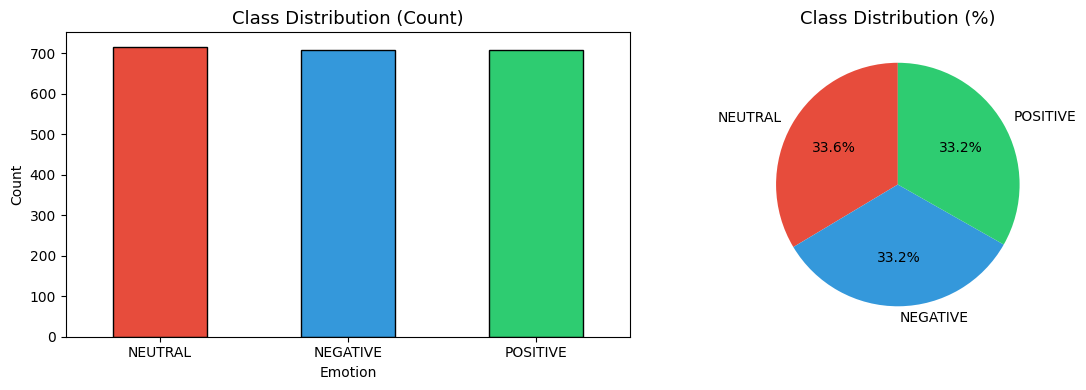

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
colors = ['#e74c3c', '#3498db', '#2ecc71']
df['label'].value_counts().plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Class Distribution (Count)', fontsize=13)
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
df['label'].value_counts().plot(kind='pie', ax=axes[1], colors=colors,
                                 autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution (%)', fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 2.2 Feature Statistics

In [5]:
feature_cols = [c for c in df.columns if c != 'label']
desc = df[feature_cols].describe().T
print(f"Feature stats summary:")
print(f"  Mean range: [{desc['mean'].min():.2f}, {desc['mean'].max():.2f}]")
print(f"  Std range:  [{desc['std'].min():.4f}, {desc['std'].max():.2f}]")
print(f"  Min value:  {desc['min'].min():.2f}")
print(f"  Max value:  {desc['max'].max():.2f}")
desc.head(10)

Feature stats summary:
  Mean range: [-510958235129.30, 4410827522013494.50]
  Std range:  [0.2626, 79389845963080480.00]
  Min value:  -1580000000000000.00
  Max value:  2610000000000000000.00


,count,mean,std,min,25%,50%,75%,max
# mean_0_a,2132.0,15.256914,15.284621,-61.3,6.5775,14.10000,27.700,304.0
mean_1_a,2132.0,27.012462,9.265141,-114.0,26.0750,30.00000,31.400,42.3
mean_2_a,2132.0,-104.975629,206.271960,-970.0,-195.0000,14.95000,29.600,661.0
mean_3_a,2132.0,13.605898,16.874676,-137.0,4.8575,15.40000,26.500,206.0
mean_4_a,2132.0,24.150483,14.187340,-217.0,23.6000,25.20000,26.800,213.0
mean_d_0_a,2132.0,0.025378,17.981796,-218.0,-3.1050,-0.04460,2.920,402.0
mean_d_1_a,2132.0,0.052282,8.509174,-255.0,-1.3400,0.13200,1.540,257.0
mean_d_2_a,2132.0,0.301655,68.098894,-1360.0,-4.0025,0.95750,6.735,1150.0
mean_d_3_a,2132.0,0.036793,17.010031,-203.0,-2.9050,-0.09975,2.535,349.0
mean_d_4_a,2132.0,0.083567,18.935378,-553.0,-2.6225,0.14650,2.870,444.0


### 2.3 Distribution of Selected Features by Emotion

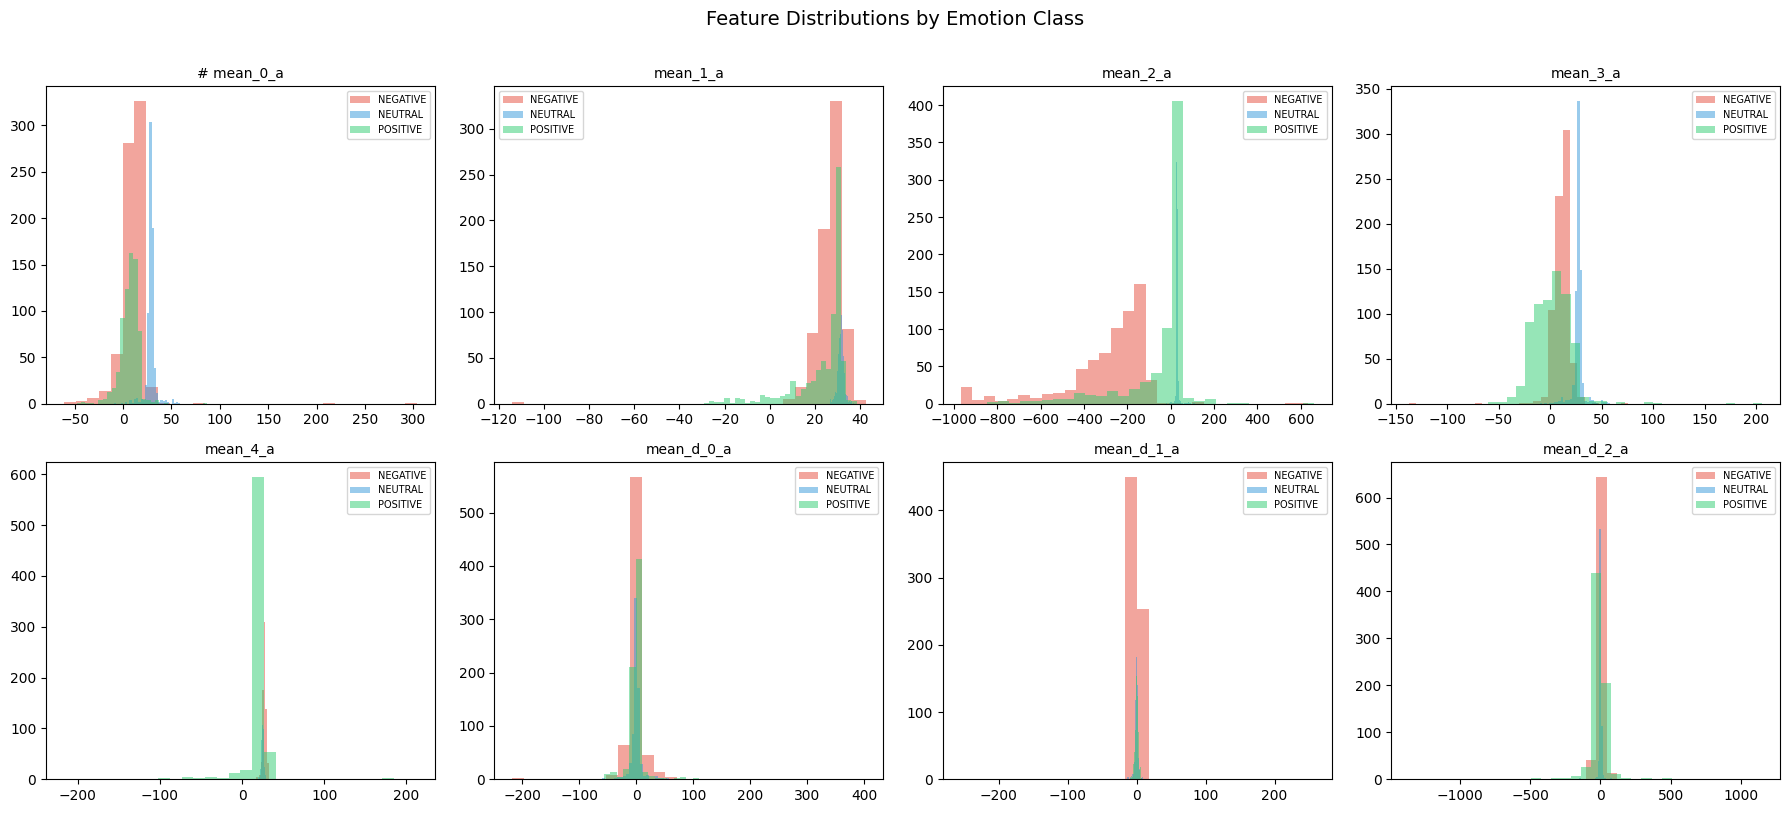

In [6]:
sample_features = feature_cols[:8]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(sample_features):
    for label, color in zip(['NEGATIVE', 'NEUTRAL', 'POSITIVE'], colors):
        subset = df[df['label'] == label][feat]
        axes[i].hist(subset, bins=30, alpha=0.5, label=label, color=color)
    axes[i].set_title(feat, fontsize=10)
    axes[i].legend(fontsize=7)

plt.suptitle('Feature Distributions by Emotion Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 2.4 Correlation Heatmap (Top 30 Features by Variance)

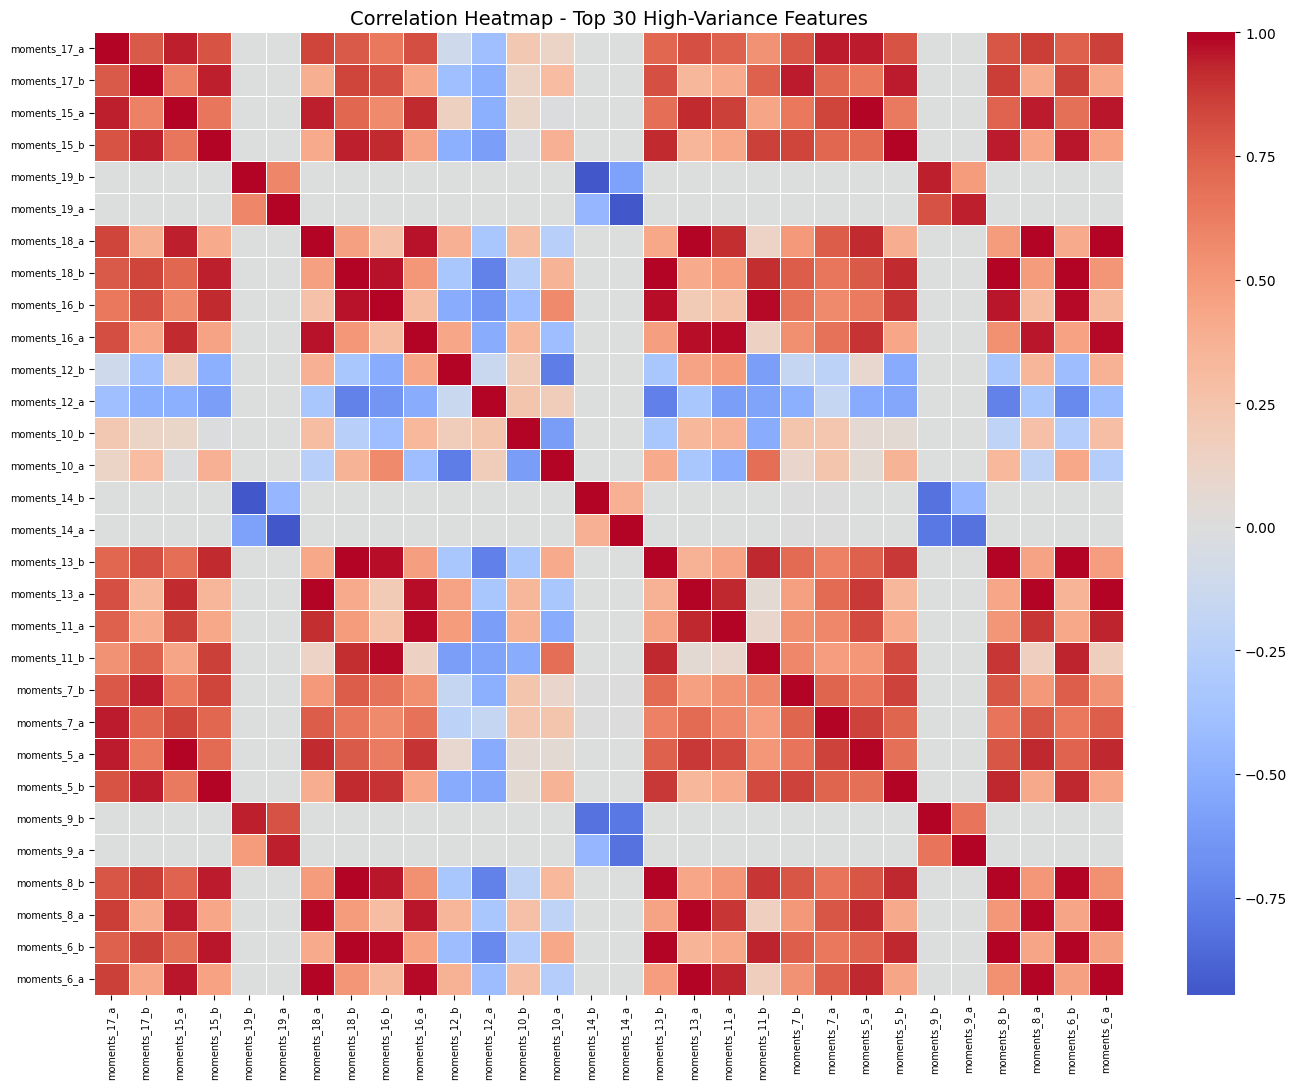

In [7]:
top_var_features = df[feature_cols].var().nlargest(30).index.tolist()
corr = df[top_var_features].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap='coolwarm', center=0, fmt='.1f',
            xticklabels=True, yticklabels=True, linewidths=0.5)
plt.title('Correlation Heatmap - Top 30 High-Variance Features', fontsize=14)
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

### 2.5 PCA Visualization (2D)

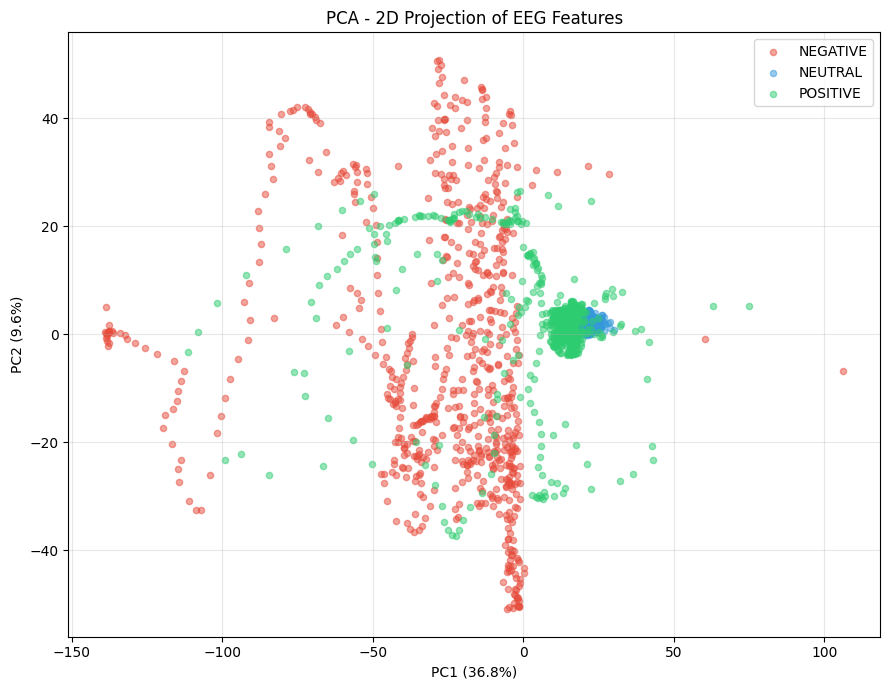

Explained variance (first 10 PCs): 46.3%


In [8]:
X = df[feature_cols].values
y = df['label'].values

scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X)

pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled_pca)

plt.figure(figsize=(9, 7))
for label, color in zip(['NEGATIVE', 'NEUTRAL', 'POSITIVE'], colors):
    mask = y == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=label, alpha=0.5, s=20)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA - 2D Projection of EEG Features')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Explained variance (first 10 PCs): {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")

### 2.6 Boxplots by Emotion

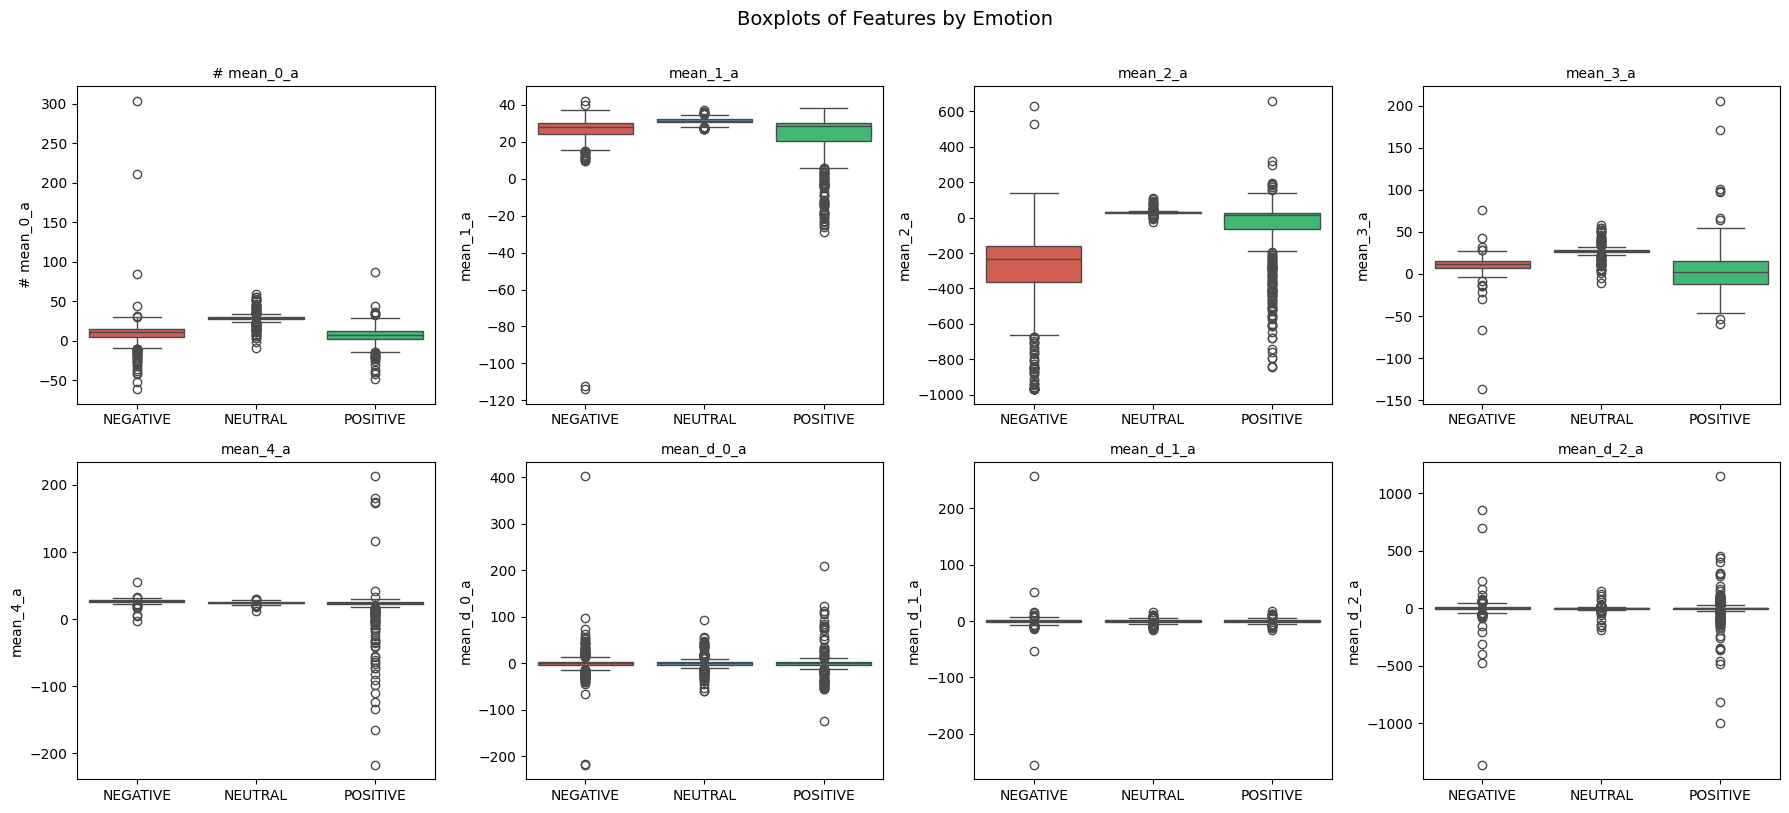

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(sample_features):
    sns.boxplot(data=df, x='label', y=feat, ax=axes[i], palette=colors,
                order=['NEGATIVE', 'NEUTRAL', 'POSITIVE'])
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('')

plt.suptitle('Boxplots of Features by Emotion', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3. Data Preparation

In [10]:
le = LabelEncoder()
y_encoded = le.fit_transform(df['label'])
print("Classes:", le.classes_, "-> Encoded:", np.unique(y_encoded))

X = df[feature_cols].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")
print(f"Train label distribution: {np.bincount(y_train)}")
print(f"Test label distribution:  {np.bincount(y_test)}")

Classes: ['NEGATIVE' 'NEUTRAL' 'POSITIVE'] -> Encoded: [0 1 2]

Train: (1705, 2548), Test: (427, 2548)
Train label distribution: [566 573 566]
Test label distribution:  [142 143 142]


## 4. Classical ML Models

In [11]:
results = {}

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    results[name] = acc
    print(f"\n{'='*50}")
    print(f"{name} â€” Accuracy: {acc:.4f}")
    print(f"{'='*50}")
    print(classification_report(y_te, y_pred, target_names=le.classes_))
    return y_pred

### 4.1 Logistic Regression

In [12]:
evaluate_model("Logistic Regression",
               LogisticRegression(max_iter=1000, random_state=42),
               X_train_scaled, X_test_scaled, y_train, y_test);


Logistic Regression â€” Accuracy: 0.9719
              precision    recall  f1-score   support

    NEGATIVE       0.95      0.98      0.96       142
     NEUTRAL       0.99      1.00      1.00       143
    POSITIVE       0.98      0.94      0.96       142

    accuracy                           0.97       427
   macro avg       0.97      0.97      0.97       427
weighted avg       0.97      0.97      0.97       427



### 4.2 SVM (RBF Kernel)

In [13]:
evaluate_model("SVM (RBF)",
               SVC(kernel='rbf', random_state=42),
               X_train_scaled, X_test_scaled, y_train, y_test);


SVM (RBF) â€” Accuracy: 0.9485
              precision    recall  f1-score   support

    NEGATIVE       0.90      0.98      0.94       142
     NEUTRAL       0.99      0.99      0.99       143
    POSITIVE       0.96      0.88      0.92       142

    accuracy                           0.95       427
   macro avg       0.95      0.95      0.95       427
weighted avg       0.95      0.95      0.95       427



### 4.3 Random Forest

In [14]:
evaluate_model("Random Forest",
               RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
               X_train_scaled, X_test_scaled, y_train, y_test);


Random Forest â€” Accuracy: 0.9859
              precision    recall  f1-score   support

    NEGATIVE       0.98      0.99      0.98       142
     NEUTRAL       0.99      1.00      1.00       143
    POSITIVE       0.99      0.97      0.98       142

    accuracy                           0.99       427
   macro avg       0.99      0.99      0.99       427
weighted avg       0.99      0.99      0.99       427



### 4.4 XGBoost

In [15]:
evaluate_model("XGBoost",
               XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                             random_state=42, use_label_encoder=False,
                             eval_metric='mlogloss'),
               X_train_scaled, X_test_scaled, y_train, y_test);


XGBoost â€” Accuracy: 0.9953
              precision    recall  f1-score   support

    NEGATIVE       0.99      1.00      0.99       142
     NEUTRAL       1.00      1.00      1.00       143
    POSITIVE       1.00      0.99      0.99       142

    accuracy                           1.00       427
   macro avg       1.00      1.00      1.00       427
weighted avg       1.00      1.00      1.00       427



### 4.5 LightGBM

In [16]:
evaluate_model("LightGBM",
               LGBMClassifier(n_estimators=200, learning_rate=0.1, random_state=42,
                              verbose=-1),
               X_train_scaled, X_test_scaled, y_train, y_test);


LightGBM â€” Accuracy: 0.9953
              precision    recall  f1-score   support

    NEGATIVE       0.99      1.00      0.99       142
     NEUTRAL       1.00      1.00      1.00       143
    POSITIVE       1.00      0.99      0.99       142

    accuracy                           1.00       427
   macro avg       1.00      1.00      1.00       427
weighted avg       1.00      1.00      1.00       427



## 5. Deep Learning Models (PyTorch â€” CPU)

In [17]:
device = torch.device('cpu')
num_classes = len(le.classes_)
input_dim = X_train_scaled.shape[1]

X_train_t = torch.FloatTensor(X_train_scaled)
X_test_t = torch.FloatTensor(X_test_scaled)
y_train_t = torch.LongTensor(y_train)
y_test_t = torch.LongTensor(y_test)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

print(f"Input dim: {input_dim}, Classes: {num_classes}")

Input dim: 2548, Classes: 3


In [18]:
def train_model(model, train_loader, test_loader, epochs=50, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # Train
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_correct += (outputs.argmax(1) == y_batch).sum().item()
            train_total += X_batch.size(0)

        # Eval
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)
                val_correct += (outputs.argmax(1) == y_batch).sum().item()
                val_total += X_batch.size(0)

        t_loss = train_loss / train_total
        v_loss = val_loss / val_total
        t_acc = train_correct / train_total
        v_acc = val_correct / val_total

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        scheduler.step(v_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | "
                  f"Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}")

    return history


def evaluate_dl_model(name, model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds = model(X_batch).argmax(1)
            all_preds.extend(preds.numpy())
            all_labels.extend(y_batch.numpy())
    acc = accuracy_score(all_labels, all_preds)
    results[name] = acc
    print(f"\n{'='*50}")
    print(f"{name} â€” Accuracy: {acc:.4f}")
    print(f"{'='*50}")
    print(classification_report(all_labels, all_preds, target_names=le.classes_))
    return all_preds


def plot_training(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['train_loss'], label='Train')
    ax1.plot(history['val_loss'], label='Val')
    ax1.set_title(f'{title} - Loss')
    ax1.set_xlabel('Epoch')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(history['train_acc'], label='Train')
    ax2.plot(history['val_acc'], label='Val')
    ax2.set_title(f'{title} - Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

### 5.1 MLP (Multi-Layer Perceptron)

In [19]:
class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

mlp = MLP(input_dim, num_classes)
print(mlp)
print(f"Parameters: {sum(p.numel() for p in mlp.parameters()):,}")

MLP(
  (net): Sequential(
    (0): Linear(in_features=2548, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=128, out_features=3, bias=True)
  )
)
Parameters: 1,471,491


Epoch  10/30 | Train Loss: 0.0460 Acc: 0.9842 | Val Loss: 0.0755 Acc: 0.9719


Epoch  20/30 | Train Loss: 0.0080 Acc: 0.9977 | Val Loss: 0.0870 Acc: 0.9789


Epoch  30/30 | Train Loss: 0.0042 Acc: 0.9988 | Val Loss: 0.1104 Acc: 0.9813


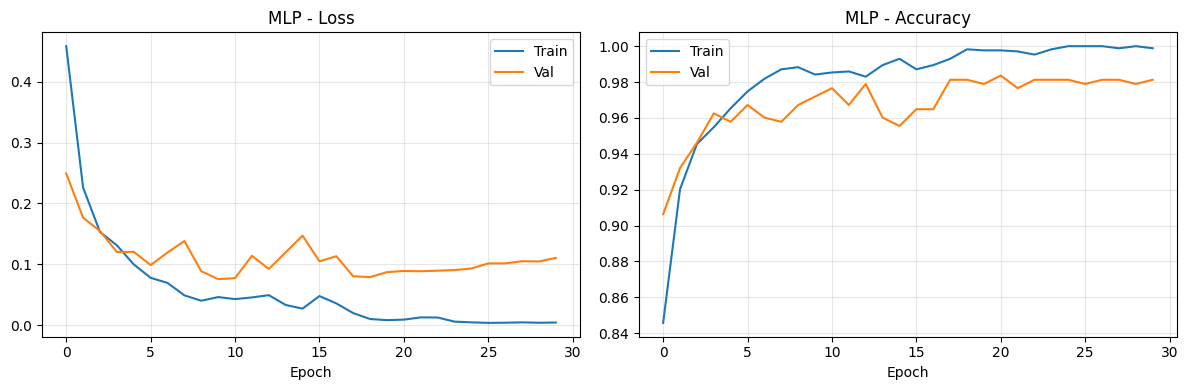


MLP â€” Accuracy: 0.9813
              precision    recall  f1-score   support

    NEGATIVE       0.97      0.98      0.97       142
     NEUTRAL       1.00      1.00      1.00       143
    POSITIVE       0.98      0.96      0.97       142

    accuracy                           0.98       427
   macro avg       0.98      0.98      0.98       427
weighted avg       0.98      0.98      0.98       427



In [20]:
mlp_history = train_model(mlp, train_loader, test_loader, epochs=30, lr=1e-3)
plot_training(mlp_history, "MLP")
evaluate_dl_model("MLP", mlp, test_loader);

### 5.2 1D-CNN

In [21]:
class CNN1D(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(4),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(4),
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(1)  # (B, 1, features)
        x = self.conv(x)
        x = x.squeeze(-1)
        return self.classifier(x)

cnn = CNN1D(input_dim, num_classes)
print(cnn)
print(f"Parameters: {sum(p.numel() for p in cnn.parameters()):,}")

CNN1D(
  (conv): Sequential(
    (0): Conv1d(1, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=256, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features

Epoch  10/30 | Train Loss: 0.1063 Acc: 0.9613 | Val Loss: 0.2914 Acc: 0.9204


Epoch  20/30 | Train Loss: 0.0592 Acc: 0.9824 | Val Loss: 0.1441 Acc: 0.9344


Epoch  30/30 | Train Loss: 0.0147 Acc: 0.9965 | Val Loss: 0.0638 Acc: 0.9859


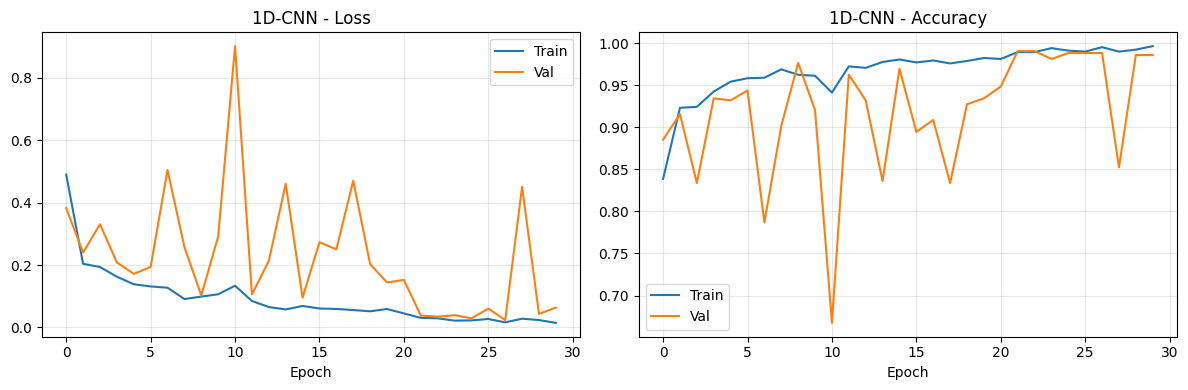


1D-CNN â€” Accuracy: 0.9859
              precision    recall  f1-score   support

    NEGATIVE       1.00      0.96      0.98       142
     NEUTRAL       1.00      1.00      1.00       143
    POSITIVE       0.96      1.00      0.98       142

    accuracy                           0.99       427
   macro avg       0.99      0.99      0.99       427
weighted avg       0.99      0.99      0.99       427



In [22]:
cnn_history = train_model(cnn, train_loader, test_loader, epochs=30, lr=1e-3)
plot_training(cnn_history, "1D-CNN")
evaluate_dl_model("1D-CNN", cnn, test_loader);

### 5.3 Transformer Encoder

In [23]:
class EEGTransformer(nn.Module):
    """
    Treats the 2548 features as a sequence of patches.
    Each patch is a group of features projected into an embedding space.
    """
    def __init__(self, input_dim, num_classes, patch_size=52, d_model=64,
                 nhead=4, num_layers=2, dim_ff=128, dropout=0.2):
        super().__init__()
        self.patch_size = patch_size
        num_patches = input_dim // patch_size
        self.num_patches = num_patches
        self.trim_dim = num_patches * patch_size

        self.patch_proj = nn.Linear(patch_size, d_model)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, d_model))
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        B = x.size(0)
        x = x[:, :self.trim_dim]
        x = x.view(B, self.num_patches, self.patch_size)
        x = self.patch_proj(x)

        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_embed
        x = self.dropout(x)

        x = self.transformer(x)
        x = self.norm(x[:, 0])
        return self.head(x)

transformer = EEGTransformer(input_dim, num_classes)
print(transformer)
print(f"Parameters: {sum(p.numel() for p in transformer.parameters()):,}")

EEGTransformer(
  (patch_proj): Linear(in_features=52, out_features=64, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): D

Epoch  10/30 | Train Loss: 0.1813 Acc: 0.9396 | Val Loss: 0.1660 Acc: 0.9344


Epoch  20/30 | Train Loss: 0.1371 Acc: 0.9613 | Val Loss: 0.1070 Acc: 0.9672


Epoch  30/30 | Train Loss: 0.1040 Acc: 0.9654 | Val Loss: 0.1354 Acc: 0.9555


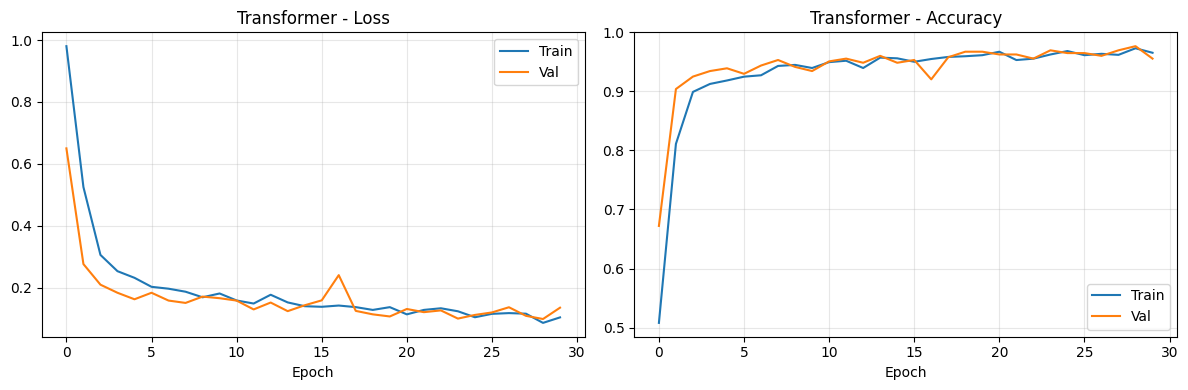


Transformer â€” Accuracy: 0.9555
              precision    recall  f1-score   support

    NEGATIVE       0.94      0.96      0.95       142
     NEUTRAL       0.96      1.00      0.98       143
    POSITIVE       0.96      0.91      0.93       142

    accuracy                           0.96       427
   macro avg       0.96      0.96      0.96       427
weighted avg       0.96      0.96      0.96       427



In [24]:
transformer_history = train_model(transformer, train_loader, test_loader, epochs=30, lr=1e-3)
plot_training(transformer_history, "Transformer")
evaluate_dl_model("Transformer", transformer, test_loader);

## 6. Model Comparison

In [25]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df['Accuracy (%)'] = (results_df['Accuracy'] * 100).round(2)
print(results_df[['Model', 'Accuracy (%)']].to_string(index=False))

              Model  Accuracy (%)
            XGBoost         99.53
           LightGBM         99.53
             1D-CNN         98.59
      Random Forest         98.59
                MLP         98.13
Logistic Regression         97.19
        Transformer         95.55
          SVM (RBF)         94.85


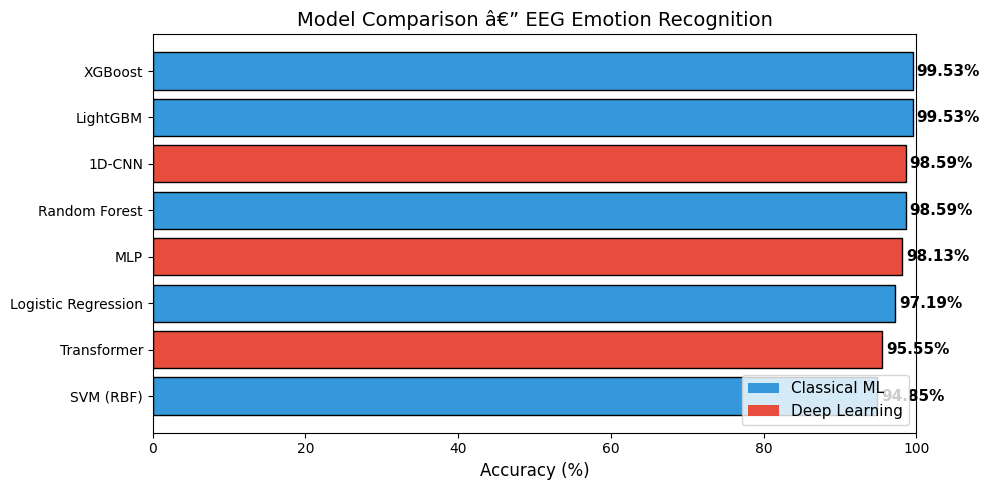

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
palette = ['#2ecc71' if 'ML' not in t else '#3498db'
           for t in results_df['Model']]
# Color: green for DL, blue for classical ML
ml_models = {'Logistic Regression', 'SVM (RBF)', 'Random Forest', 'XGBoost', 'LightGBM'}
bar_colors = ['#3498db' if m in ml_models else '#e74c3c' for m in results_df['Model']]

bars = ax.barh(results_df['Model'], results_df['Accuracy (%)'], color=bar_colors, edgecolor='black')
ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_title('Model Comparison â€” EEG Emotion Recognition', fontsize=14)
ax.set_xlim(0, 100)
ax.invert_yaxis()

for bar, acc in zip(bars, results_df['Accuracy (%)']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{acc}%', va='center', fontsize=11, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', label='Classical ML'),
                   Patch(facecolor='#e74c3c', label='Deep Learning')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

### 6.1 Confusion Matrices â€” Best ML vs Best DL

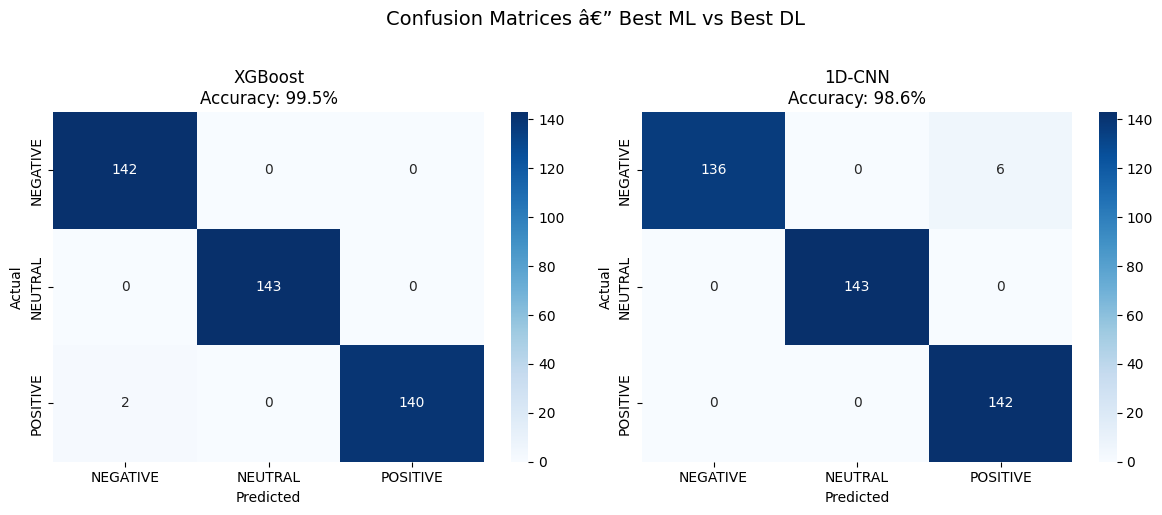

In [27]:
# Get predictions from best ML and best DL models
ml_results = {k: v for k, v in results.items() if k in ml_models}
dl_results = {k: v for k, v in results.items() if k not in ml_models}

best_ml_name = max(ml_results, key=ml_results.get)
best_dl_name = max(dl_results, key=dl_results.get)

# Re-predict for confusion matrices
# Best ML
ml_model_map = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                              random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
    'LightGBM': LGBMClassifier(n_estimators=200, learning_rate=0.1, random_state=42, verbose=-1),
}
best_ml = ml_model_map[best_ml_name]
best_ml.fit(X_train_scaled, y_train)
y_pred_ml = best_ml.predict(X_test_scaled)

# Best DL
dl_model_map = {'MLP': mlp, '1D-CNN': cnn, 'Transformer': transformer}
best_dl = dl_model_map[best_dl_name]
best_dl.eval()
with torch.no_grad():
    y_pred_dl = best_dl(X_test_t).argmax(1).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name, y_pred in zip(axes, [best_ml_name, best_dl_name], [y_pred_ml, y_pred_dl]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_title(f'{name}\nAccuracy: {accuracy_score(y_test, y_pred)*100:.1f}%', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices â€” Best ML vs Best DL', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()